# EDA và Phân tích Điểm thi THPT 2023

**Người thực hiện:** Kiên (Data Analyst)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Hỗ trợ hiển thị tiếng Việt tránh lỗi font
plt.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. Tải và xem trước dữ liệu

In [2]:
# Đọc dữ liệu đã được làm sạch
df = pd.read_csv('diem_thi_thpt_2023_clean.csv', dtype={'sbd': str, 'ma_tinh': str})
df.head()

,sbd,ma_tinh,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd,diem_liet
0,01000001,01,8.4,8.50,9.2,NaN,NaN,NaN,6.75,6.00,9.00,False
1,01000002,01,7.2,8.50,9.2,NaN,NaN,NaN,8.75,6.50,8.50,False
2,01000003,01,NaN,6.50,NaN,NaN,NaN,NaN,9.25,7.50,NaN,False
3,01000004,01,7.8,8.25,7.8,NaN,NaN,NaN,4.50,6.25,8.25,False
4,01000005,01,7.2,8.00,7.8,NaN,NaN,NaN,4.75,6.75,8.25,False


## 2. Thống kê mô tả (EDA)

In [8]:
subjects = ['toan', 'ngu_van', 'ngoai_ngu', 'vat_li', 'hoa_hoc', 'sinh_hoc', 'lich_su', 'dia_li', 'gdcd']
df[subjects].describe()

,toan,ngu_van,ngoai_ngu,vat_li,hoa_hoc,sinh_hoc,lich_su,dia_li,gdcd
count,1.003373e+06,1.008239e+06,880997.000000,327189.000000,328118.000000,324625.000000,683447.000000,682134.000000,565452.000000
mean,6.250557e+00,6.858194e+00,5.462410,6.573900,6.744646,6.394933,6.025629,6.147523,8.285805
std,1.633336e+00,1.326471e+00,1.966353,1.486819,1.428468,1.206772,1.552931,1.168732,1.137638
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.200000e+00,6.000000e+00,4.000000,5.500000,5.750000,5.500000,5.000000,5.500000,7.750000
50%,6.600000e+00,7.000000e+00,5.200000,6.750000,7.000000,6.500000,6.000000,6.250000,8.500000
75%,7.600000e+00,7.750000e+00,7.000000,7.750000,7.750000,7.250000,7.250000,7.000000,9.250000
max,1.000000e+01,1.000000e+01,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


**📝 Nhận xét phân tích:**
- Quan sát bảng thống kê (describe) trên, ta có thể thấy số lượng thí sinh dự thi của từng môn (count) có sự chênh lệch do lựa chọn tổ hợp môn KHTN và KHXH.
- Xem xét điểm trung bình (mean) và trung vị (50%) để biết mặt bằng chung của từng môn. Ví dụ: Môn GDCD thường có điểm trung bình rất cao, trong khi Ngoại ngữ hoặc Lịch sử thường thấp hơn.
- Giá trị max, min cho thấy có tồn tại điểm 10 tuyệt đối hay điểm liệt ở các môn hay không.

## 3. Tính toán các khối thi cơ bản và Phân tích

In [4]:
# Tính tổng điểm các khối thi
df['A00'] = df['toan'] + df['vat_li'] + df['hoa_hoc']
df['A01'] = df['toan'] + df['vat_li'] + df['ngoai_ngu']
df['B00'] = df['toan'] + df['hoa_hoc'] + df['sinh_hoc']
df['C00'] = df['ngu_van'] + df['lich_su'] + df['dia_li']
df['D01'] = df['toan'] + df['ngu_van'] + df['ngoai_ngu']

blocks = ['A00', 'A01', 'B00', 'C00', 'D01']
df[blocks].describe()

,A00,A01,B00,C00,D01
count,325902.000000,315146.000000,324554.000000,681723.000000,878007.000000
mean,20.774499,20.275288,20.604733,18.974926,18.903006
std,3.094093,3.339521,2.776287,3.378895,3.818043
min,0.450000,5.050000,4.500000,0.000000,2.800000
25%,18.900000,18.100000,18.900000,16.750000,16.250000
50%,21.150000,20.450000,20.850000,19.000000,19.050000
75%,23.000000,22.700000,22.500000,21.250000,21.750000
max,29.350000,29.800000,29.800000,29.500000,28.900000


**📝 Nhận xét phân tích Khối thi:**
- Các khối thi có mức điểm tối đa là 30. Ta sẽ xem khối nào có mức điểm trung bình cao nhất.
- Mức điểm phân hóa giữa các khối A00 và D01 thường cho thấy xu hướng chọn ngành của học sinh trong năm nay.

## 4. Trực quan hóa và Phân tích chuyên sâu
### 4.1. Phổ điểm các môn học (Phân phối chuẩn)

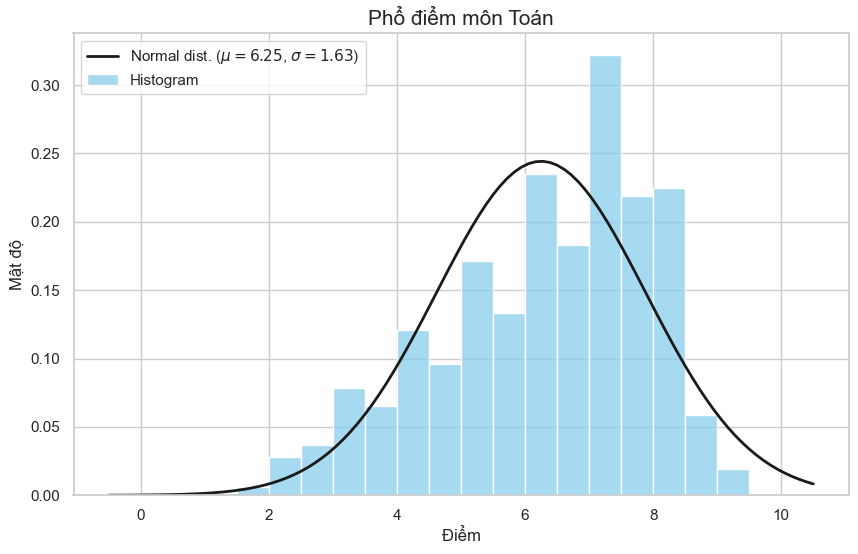

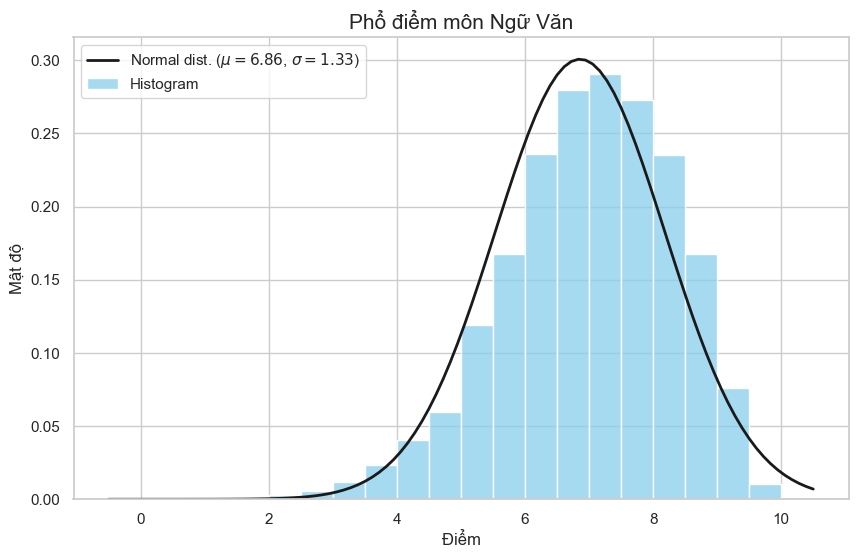

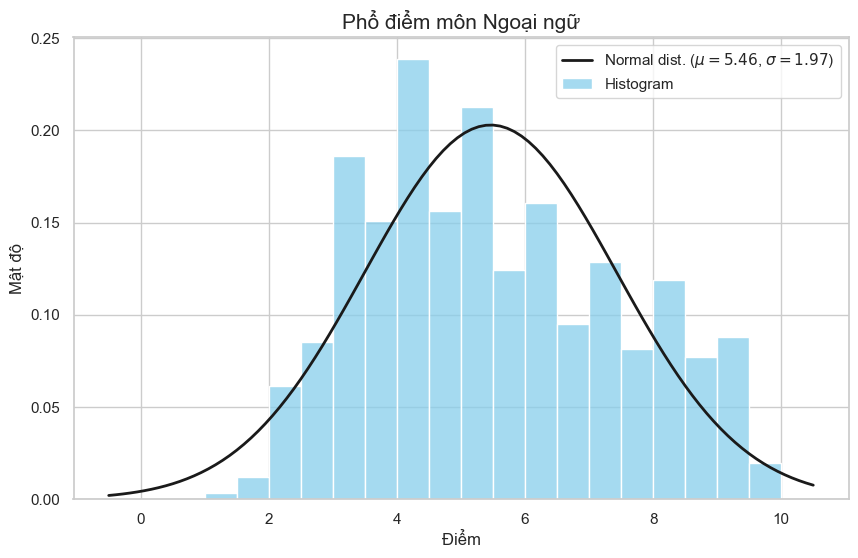

In [5]:
# Hàm vẽ phổ điểm
def plot_distribution(data, column, title, filename=None):
    plt.figure(figsize=(10, 6))
    valid_data = data[column].dropna()
    
    sns.histplot(valid_data, bins=20, kde=False, stat='density', color='skyblue', label='Histogram')
    
    mu, std = norm.fit(valid_data)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2, label=f'Normal dist. ($\mu={mu:.2f}$, $\sigma={std:.2f}$)')
    
    plt.title(title, fontsize=15)
    plt.xlabel('Điểm', fontsize=12)
    plt.ylabel('Mật độ', fontsize=12)
    plt.legend()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

plot_distribution(df, 'toan', 'Phổ điểm môn Toán', 'hist_toan.png')
plot_distribution(df, 'ngu_van', 'Phổ điểm môn Ngữ Văn', 'hist_ngu_van.png')
plot_distribution(df, 'ngoai_ngu', 'Phổ điểm môn Ngoại ngữ', 'hist_ngoai_ngu.png')

**📝 Nhận xét hình dáng Phổ điểm:**
- **Môn Toán & Ngữ Văn:** Phổ điểm thường có dạng hình chuông khá chuẩn (đối xứng) bám sát đường phân phối chuẩn (Normal Distribution). Điểm tập trung nhiều nhất ở khoảng 6-7.
- **Môn Ngoại ngữ:** Đáng chú ý ở môn Tiếng Anh thường xuất hiện phổ điểm lệch (Skewed) hoặc có hai đỉnh (Bimodal). Điều này phản ánh rõ sự phân hóa năng lực ngoại ngữ giữa các khu vực thành thị và nông thôn.

### 4.2. Heatmap tương quan (Correlation) giữa các môn học

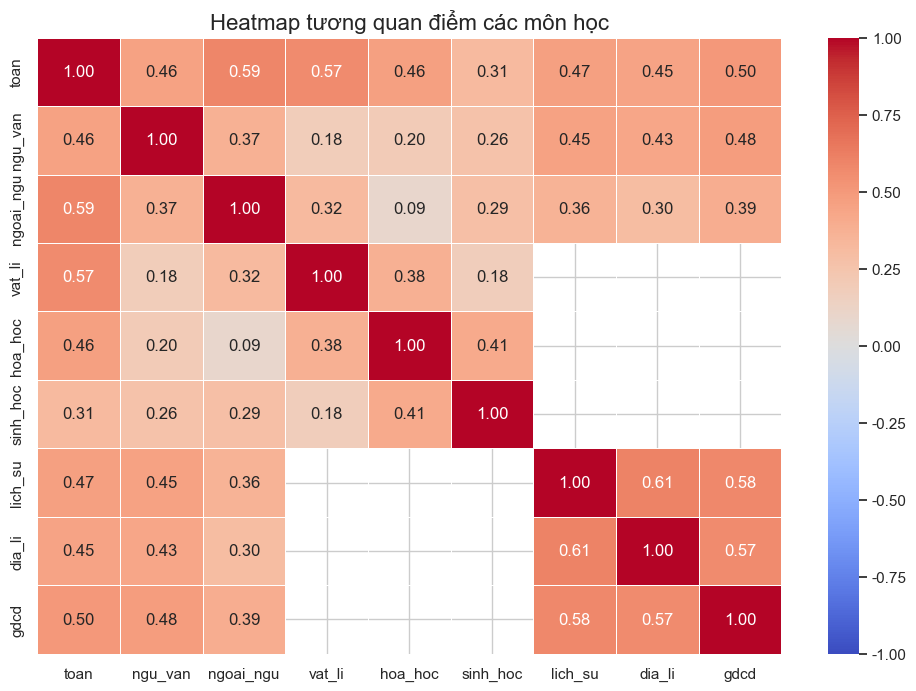

In [6]:
plt.figure(figsize=(12, 8))
corr_matrix = df[subjects].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Heatmap tương quan điểm các môn học', fontsize=16)
plt.savefig('heatmap_mon.png', dpi=300, bbox_inches='tight')
plt.show()

**📝 Nhận xét độ tương quan:**
- Hệ số tương quan (r) gần `1` chứng tỏ hai môn có sự liên hệ đồng biến mạnh (điểm môn này cao thì môn kia cũng cao).
- Thường thấy **Toán và Vật lí** hoặc **Toán và Hóa học** có độ tương quan dương khá lớn.
- Các môn khoa học tự nhiên ít có sự tương quan mạnh với môn Ngoại ngữ hoặc Lịch sử.

### 4.3. Boxplot so sánh phân bố và nhận diện Outliers (Điểm dị biệt)

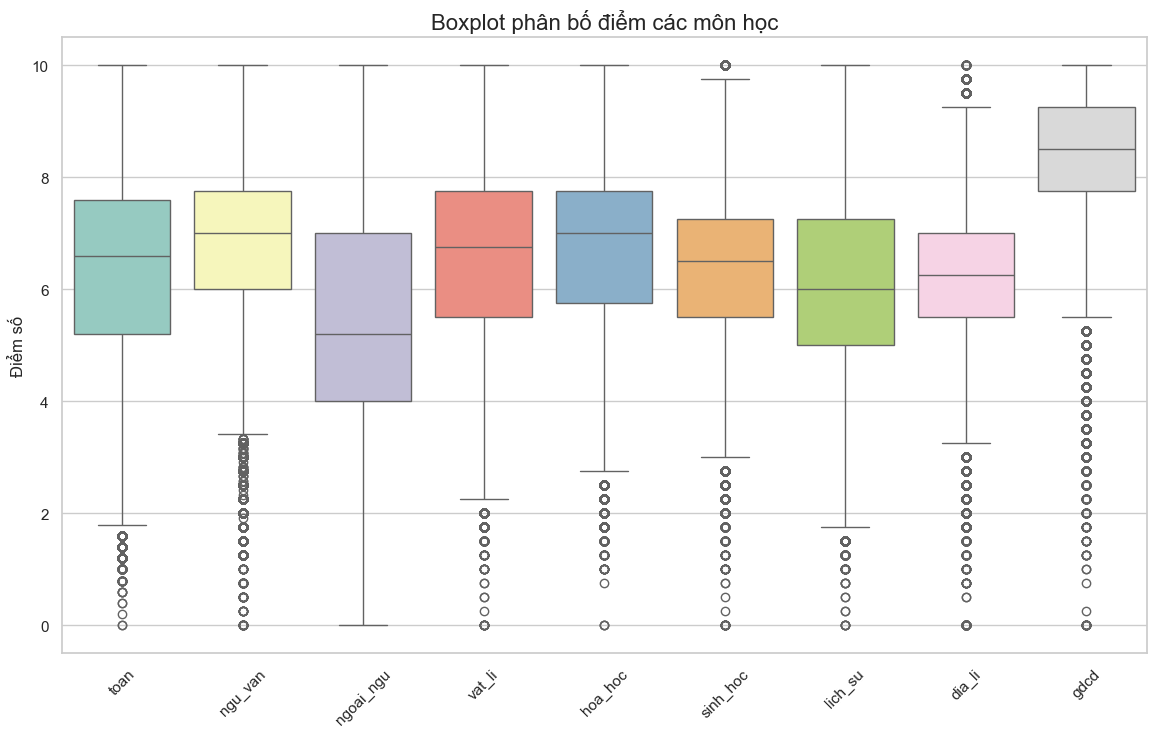

In [7]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[subjects], palette='Set3')
plt.title('Boxplot phân bố điểm các môn học', fontsize=16)
plt.ylabel('Điểm số', fontsize=12)
plt.xticks(rotation=45)
plt.savefig('boxplot_mon.png', dpi=300, bbox_inches='tight')
plt.show()

**📝 Nhận xét Boxplot:**
- Hộp (Box) thể hiện mức độ tập trung của 50% số lượng điểm sinh viên (từ tứ phân vị thứ 1 đến thứ 3). Môn GDCD có hộp nằm ở vị trí cao nhất (chứng tỏ điểm thi mặt bằng chung rất cao).
- Các dấu chấm đen (Outliers) phía dưới thể hiện những thí sinh bị điểm liệt hoặc điểm quá thấp so với đa số. Ở các môn dễ lấy điểm như GDCD sẽ xuất hiện các outlier điểm thấp, ngược lại ở môn khó như Lịch Sử có thể xuất hiện outlier điểm cao.